In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful ✅')

All imports successful ✅


In [5]:
df=pd.read_csv(r"C:\Users\nagav\Downloads\application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print(f"Shape       : {df.shape}")
print(f"Duplicates  : {df.duplicated().sum()}")
print(f"\nTarget distribution:")
print(df['TARGET'].value_counts(normalize=True).mul(100).round(2).to_string())

Shape       : (307511, 122)
Duplicates  : 0

Target distribution:
TARGET
0    91.93
1     8.07


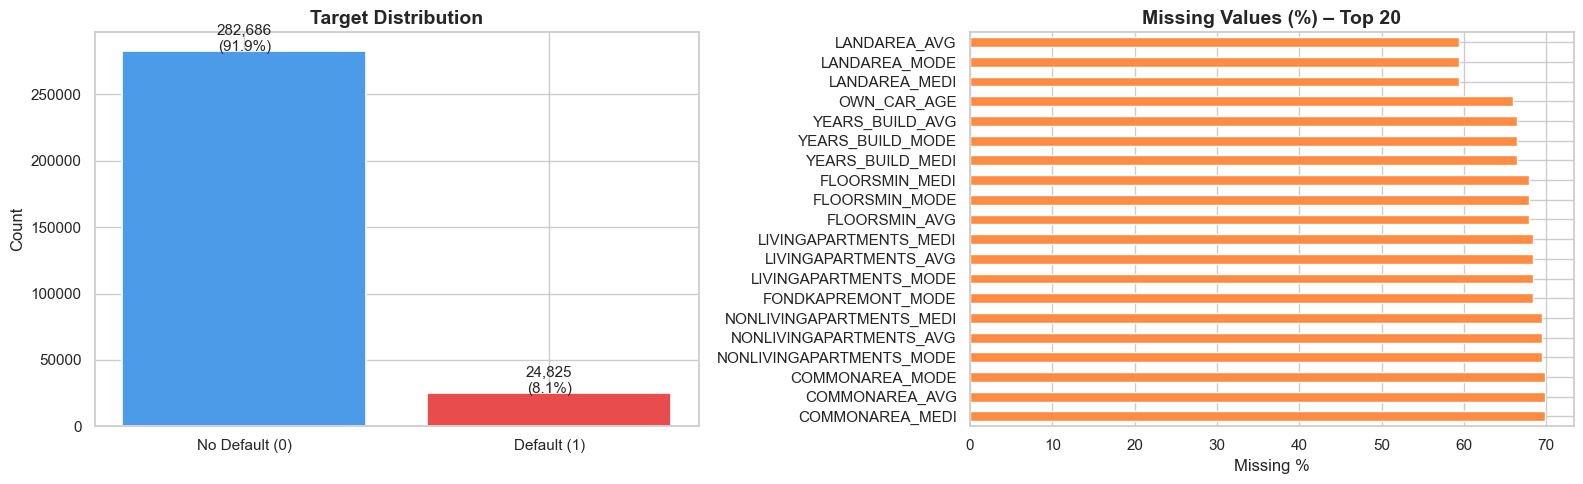

Class imbalance ratio: 1:11


In [7]:
# Missing value heatmap (top 20 columns)
missing = df.isnull().mean().mul(100).sort_values(ascending=False)
missing_top = missing[missing > 0].head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: target distribution
target_counts = df['TARGET'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values,
            color=['#4C9BE8', '#E84C4C'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Right: missing values
if len(missing_top) > 0:
    missing_top.plot(kind='barh', ax=axes[1], color='#FF8C42')
    axes[1].set_title('Missing Values (%) – Top 20', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Missing %')
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    axes[1].set_title('Missing Values', fontsize=14)

plt.tight_layout()
plt.show()
print(f"Class imbalance ratio: 1:{target_counts[0]//max(target_counts[1],1)}")

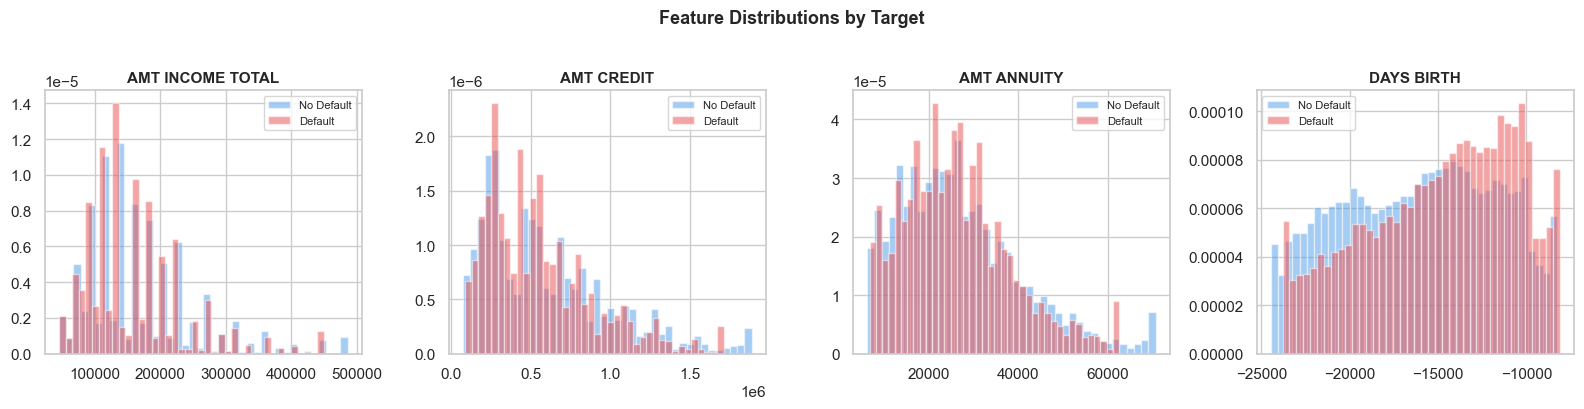

In [8]:
# Key numeric distributions by target
num_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH']
num_features = [f for f in num_features if f in df.columns]

fig, axes = plt.subplots(1, len(num_features), figsize=(16, 4))
if len(num_features) == 1:
    axes = [axes]

for ax, col in zip(axes, num_features):
    for target_val, color, label in [(0, '#4C9BE8', 'No Default'), (1, '#E84C4C', 'Default')]:
        subset = df[df['TARGET'] == target_val][col].dropna()
        # clip extreme values for readability
        p1, p99 = subset.quantile(0.01), subset.quantile(0.99)
        subset = subset.clip(p1, p99)
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Target', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
df_fe = df.copy()

# ── Domain-driven features ────────────────────────────────────────────────────
if 'DAYS_BIRTH' in df_fe.columns:
    df_fe['AGE_YEARS'] = (-df_fe['DAYS_BIRTH'] / 365).round(1)

if 'DAYS_EMPLOYED' in df_fe.columns:
    # 365243 is a sentinel for "never employed" in the dataset
    df_fe['DAYS_EMPLOYED_ANOM'] = (df_fe['DAYS_EMPLOYED'] == 365243).astype(int)
    df_fe['DAYS_EMPLOYED'] = df_fe['DAYS_EMPLOYED'].replace(365243, np.nan)
    df_fe['EMPLOYED_YEARS'] = (-df_fe['DAYS_EMPLOYED'] / 365).clip(lower=0)

if 'AMT_CREDIT' in df_fe.columns and 'AMT_INCOME_TOTAL' in df_fe.columns:
    df_fe['CREDIT_INCOME_RATIO'] = df_fe['AMT_CREDIT'] / (df_fe['AMT_INCOME_TOTAL'] + 1)

if 'AMT_ANNUITY' in df_fe.columns and 'AMT_INCOME_TOTAL' in df_fe.columns:
    df_fe['ANNUITY_INCOME_RATIO'] = df_fe['AMT_ANNUITY'] / (df_fe['AMT_INCOME_TOTAL'] + 1)

if 'AMT_CREDIT' in df_fe.columns and 'AMT_ANNUITY' in df_fe.columns:
    df_fe['CREDIT_TERM'] = df_fe['AMT_ANNUITY'] / (df_fe['AMT_CREDIT'] + 1)

if 'AMT_GOODS_PRICE' in df_fe.columns and 'AMT_CREDIT' in df_fe.columns:
    df_fe['GOODS_CREDIT_RATIO'] = df_fe['AMT_GOODS_PRICE'] / (df_fe['AMT_CREDIT'] + 1)

if all(c in df_fe.columns for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    df_fe['EXT_SOURCE_MEAN'] = df_fe[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
    df_fe['EXT_SOURCE_MIN']  = df_fe[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)

new_features = [c for c in df_fe.columns if c not in df.columns]
print(f"✅ Created {len(new_features)} new features: {new_features}")
df_fe[new_features].describe().round(3)

✅ Created 9 new features: ['AGE_YEARS', 'DAYS_EMPLOYED_ANOM', 'EMPLOYED_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'GOODS_CREDIT_RATIO', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN']


,AGE_YEARS,DAYS_EMPLOYED_ANOM,EMPLOYED_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,GOODS_CREDIT_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_MIN
count,307511.000,307511.000,252137.000,307511.000,307499.000,307499.000,307233.000,307339.000,307339.000
mean,43.937,0.180,6.532,3.958,0.181,0.054,0.901,0.509,0.400
std,11.956,0.384,6.406,2.690,0.095,0.022,0.097,0.150,0.187
min,20.500,0.000,-0.000,0.005,0.000,0.022,0.167,0.000,0.000
25%,34.000,0.000,2.101,2.019,0.115,0.037,0.835,0.414,0.254
50%,43.200,0.000,4.515,3.265,0.163,0.050,0.894,0.525,0.403
75%,53.900,0.000,8.699,5.160,0.229,0.064,1.000,0.623,0.553
max,69.100,1.000,49.074,84.734,1.876,0.124,6.667,0.879,0.879


In [10]:
# ── Drop ID columns and separate target ───────────────────────────────────────
drop_cols = ['SK_ID_CURR', 'TARGET']
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols)
y = df_fe['TARGET'].astype(int)

# ── Encode binary/ordinal categoricals ────────────────────────────────────────
cat_cols  = X.select_dtypes(include='object').columns.tolist()
bool_cols = [c for c in cat_cols if X[c].nunique() <= 2]
high_cols = [c for c in cat_cols if X[c].nunique() > 2]

# Label-encode binary categoricals
le = LabelEncoder()
for col in bool_cols:
    X[col] = X[col].fillna('Unknown')
    X[col] = le.fit_transform(X[col].astype(str))

# One-hot encode high-cardinality categoricals
X = pd.get_dummies(X, columns=high_cols, drop_first=True, dtype=int)

# ── Train / test split (stratified) ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Total features after encoding: {X_train.shape[1]}")

Train: (246008, 237), Test: (61503, 237)
Train target balance: {0: 0.919, 1: 0.081}
Total features after encoding: 237


In [11]:
# ── Impute + scale (for Logistic Regression) ──────────────────────────────────
from sklearn.impute import SimpleImputer

num_cols_all = X_train.select_dtypes(include='number').columns.tolist()

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train[num_cols_all])
X_test_imp  = imputer.transform(X_test[num_cols_all])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# ── Apply SMOTE on training set only ──────────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_imp, y_train)
X_train_sm_scaled, _ = smote.fit_resample(X_train_scaled, y_train)
_, y_train_sm = smote.fit_resample(X_train_imp, y_train)

print(f"After SMOTE — Class 0: {(y_train_sm==0).sum():,}  Class 1: {(y_train_sm==1).sum():,}")

# Tree models use raw imputed (unscaled) data
X_train_tree = X_train_imp
X_test_tree  = X_test_imp

After SMOTE — Class 0: 226,148  Class 1: 226,148


In [12]:
results = {}

def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    """Train, evaluate and return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    roc_auc  = roc_auc_score(y_te, y_proba)
    avg_prec = average_precision_score(y_te, y_proba)
    report   = classification_report(y_te, y_pred, output_dict=True)
    f1_1     = report['1']['f1-score']
    recall_1 = report['1']['recall']
    prec_1   = report['1']['precision']

    metrics = {
        'ROC-AUC': round(roc_auc, 4),
        'Avg Precision': round(avg_prec, 4),
        'F1 (Default)': round(f1_1, 4),
        'Recall (Default)': round(recall_1, 4),
        'Precision (Default)': round(prec_1, 4),
        'y_proba': y_proba,
        'y_pred': y_pred,
        'model_obj': model,
    }
    print(f"[{model_name}] ROC-AUC: {roc_auc:.4f}  |  F1(Default): {f1_1:.4f}  |  Recall(Default): {recall_1:.4f}")
    return metrics

print("evaluate_model ready ✅")

evaluate_model ready ✅


In [13]:
# ── Model 1: Logistic Regression (baseline) ───────────────────────────────────
lr = LogisticRegression(max_iter=100, class_weight='balanced',
                        C=1.0, solver='lbfgs', n_jobs=-1, random_state=RANDOM_STATE)
results['Logistic Regression'] = evaluate_model(
    lr, X_train_sm_scaled, y_train_sm, X_test_scaled, y_test, 'Logistic Regression'
)

# ── Model 2: Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, max_depth=8, min_samples_leaf=50,
    class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE
)
results['Random Forest'] = evaluate_model(
    rf, X_train_tree, y_train, X_test_tree, y_test, 'Random Forest'
)

# ── Model 3: XGBoost ──────────────────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',           # fast histogram method
    eval_metric='auc',
    n_jobs=-1, random_state=RANDOM_STATE
)
results['XGBoost'] = evaluate_model(
    xgb, X_train_tree, y_train, X_test_tree, y_test, 'XGBoost'
)

# ── Model 4: LightGBM ─────────────────────────────────────────────────────────
lgbm = LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
)
results['LightGBM'] = evaluate_model(
    lgbm, X_train_tree, y_train, X_test_tree, y_test, 'LightGBM'
)

[Logistic Regression] ROC-AUC: 0.7437  |  F1(Default): 0.2619  |  Recall(Default): 0.6485
[Random Forest] ROC-AUC: 0.7441  |  F1(Default): 0.2624  |  Recall(Default): 0.6518
[XGBoost] ROC-AUC: 0.7634  |  F1(Default): 0.2712  |  Recall(Default): 0.6812
[LightGBM] ROC-AUC: 0.7685  |  F1(Default): 0.2759  |  Recall(Default): 0.6862


In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_cols = ['ROC-AUC', 'Avg Precision', 'F1 (Default)', 'Recall (Default)', 'Precision (Default)']
summary = pd.DataFrame(
    {name: {k: v for k, v in metrics.items() if k in summary_cols}
     for name, metrics in results.items()}
).T
summary = summary[summary_cols].astype(float)
print("\n📊 Model Comparison:")
display(summary.style.highlight_max(axis=0, color='#c6efce').format('{:.4f}'))


📊 Model Comparison:


,ROC-AUC,Avg Precision,F1 (Default),Recall (Default),Precision (Default)
Logistic Regression,0.7437,0.2304,0.2619,0.6485,0.1641
Random Forest,0.7441,0.2270,0.2624,0.6518,0.1642
XGBoost,0.7634,0.2556,0.2712,0.6812,0.1693
LightGBM,0.7685,0.2573,0.2759,0.6862,0.1727


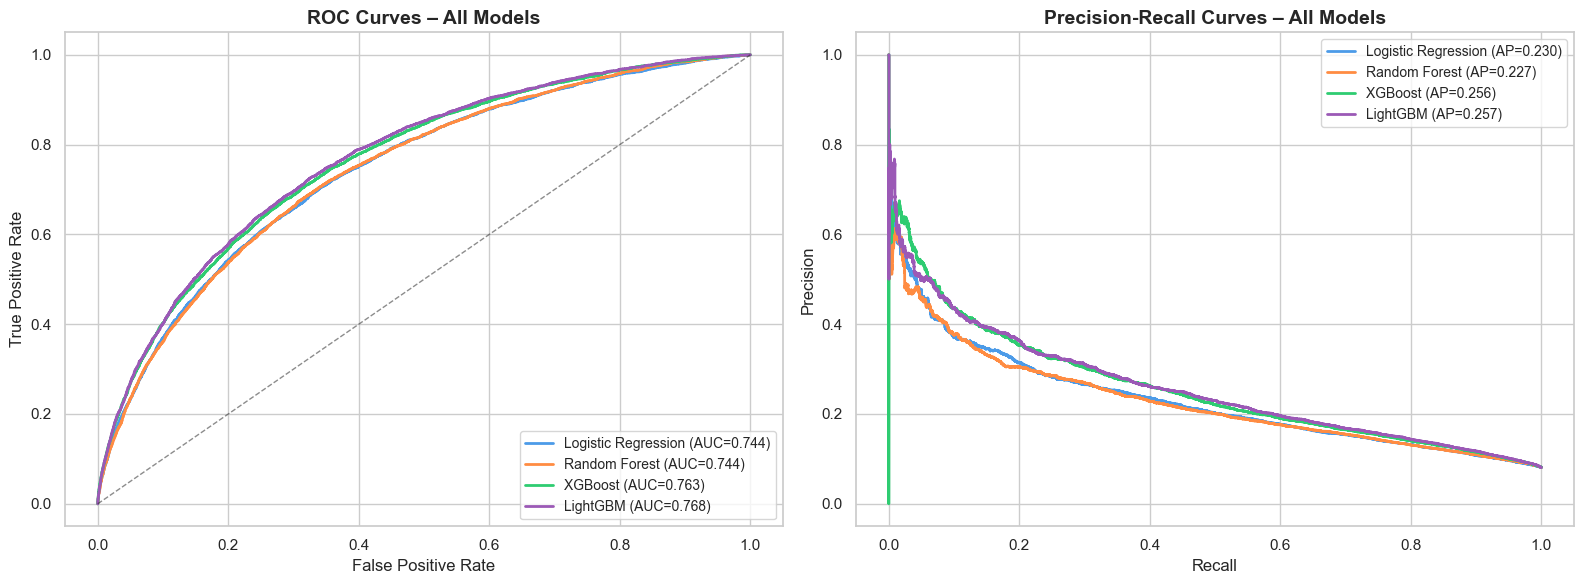

In [15]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#4C9BE8', '#FF8C42', '#2ECC71', '#9B59B6']

for (name, metrics), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_proba'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={metrics['ROC-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves – All Models', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)

# ── Precision-Recall Curves ───────────────────────────────────────────────────
for (name, metrics), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, metrics['y_proba'])
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f"{name} (AP={metrics['Avg Precision']:.3f})")

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves – All Models', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Best model: LightGBM


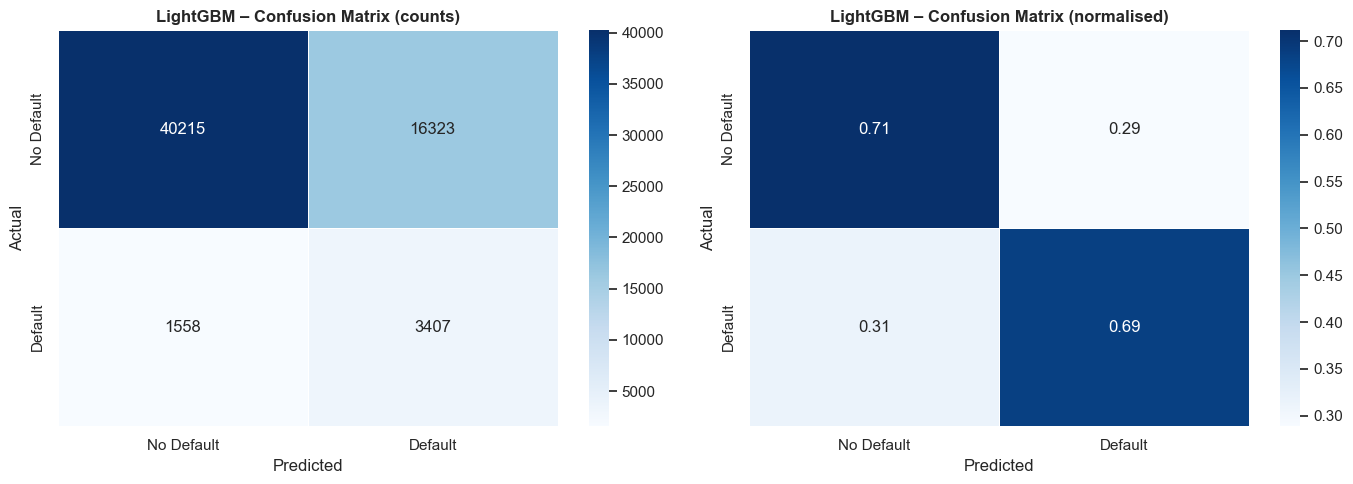

In [16]:
# ── Confusion Matrix for Best Model ───────────────────────────────────────────
best_model_name = summary['ROC-AUC'].idxmax()
best_metrics    = results[best_model_name]
print(f"Best model: {best_model_name}")

cm = confusion_matrix(y_test, best_metrics['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, fmt in [
    (axes[0], cm,      f'{best_model_name} – Confusion Matrix (counts)', 'd'),
    (axes[1], cm_norm, f'{best_model_name} – Confusion Matrix (normalised)', '.2f')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'], ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
# ── SHAP for XGBoost (or LightGBM if XGBoost isn't best) ─────────────────────
shap_model_name = 'XGBoost' if 'XGBoost' in results else 'LightGBM'
shap_model = results[shap_model_name]['model_obj']

# Use a sample for speed
sample_size = min(500, len(X_test_tree))
X_shap = X_test_tree[:sample_size]
feature_names = [str(c) for c in X_train.columns]

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)

# Handle multi-output SHAP (LightGBM returns list)
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1 (default)
else:
    sv = shap_values

print(f"SHAP values computed for {shap_model_name} ✅")

SHAP values computed for XGBoost ✅


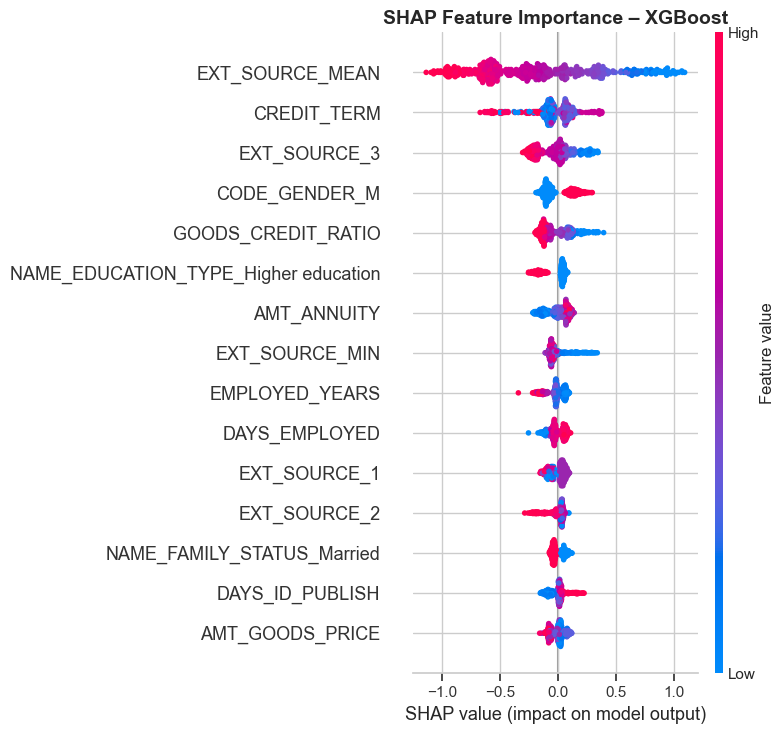

In [18]:
# ── SHAP Summary Plot ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, X_shap,
    feature_names=feature_names[:X_shap.shape[1]],
    max_display=15,
    show=False
)
plt.title(f'SHAP Feature Importance – {shap_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

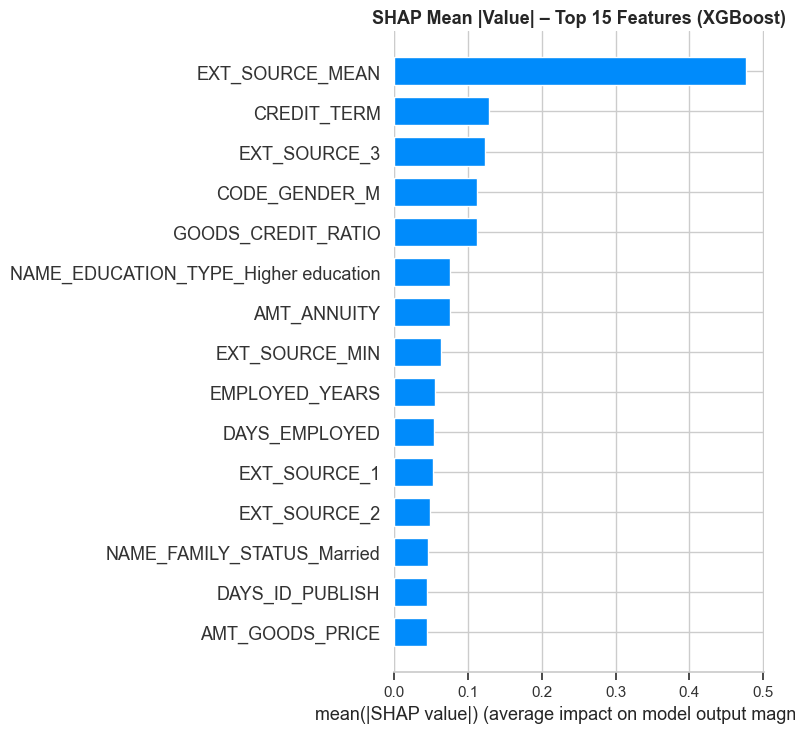

In [19]:
# ── SHAP Bar Plot (mean |SHAP|) ───────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv, X_shap,
    feature_names=feature_names[:X_shap.shape[1]],
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title(f'SHAP Mean |Value| – Top 15 Features ({shap_model_name})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Explaining sample index 200
Predicted default probability: 0.925


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


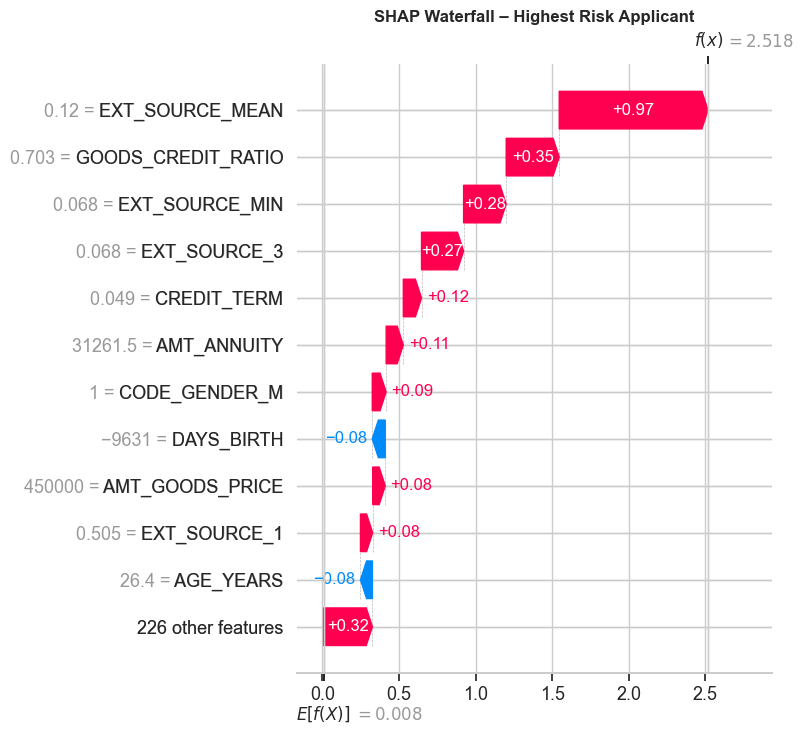

In [20]:
# ── SHAP Waterfall for a single high-risk prediction ─────────────────────────
high_risk_idx = np.argmax(results[shap_model_name]['y_proba'][:sample_size])
print(f"Explaining sample index {high_risk_idx}")
print(f"Predicted default probability: {results[shap_model_name]['y_proba'][high_risk_idx]:.3f}")

shap_exp = shap.Explanation(
    values=sv[high_risk_idx],
    base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                else explainer.expected_value[1],
    data=X_shap[high_risk_idx],
    feature_names=feature_names[:X_shap.shape[1]]
)

plt.figure()
shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.title('SHAP Waterfall – Highest Risk Applicant', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

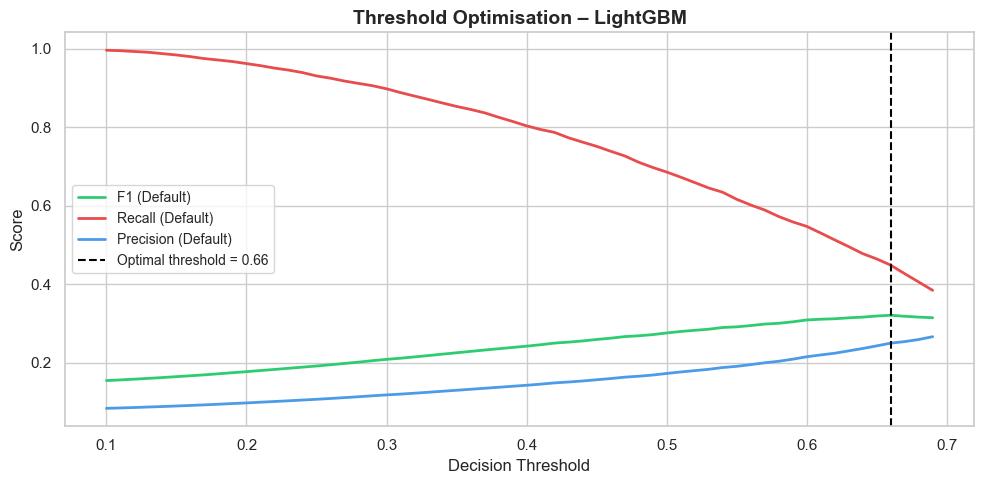


Optimal threshold: 0.66
              precision    recall  f1-score   support

  No Default       0.95      0.88      0.91     56538
     Default       0.25      0.45      0.32      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.67      0.62     61503
weighted avg       0.89      0.85      0.87     61503



In [21]:
# For credit risk, high recall on defaults is critical (minimise missed defaults)
best_proba = results[best_model_name]['y_proba']

thresholds  = np.arange(0.1, 0.7, 0.01)
f1_scores   = []
recall_scores = []
prec_scores   = []

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    rep = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    f1_scores.append(rep['1']['f1-score'])
    recall_scores.append(rep['1']['recall'])
    prec_scores.append(rep['1']['precision'])

optimal_threshold = thresholds[np.argmax(f1_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores,     label='F1 (Default)',        color='#2ECC71', lw=2)
ax.plot(thresholds, recall_scores, label='Recall (Default)',    color='#E84C4C', lw=2)
ax.plot(thresholds, prec_scores,   label='Precision (Default)', color='#4C9BE8', lw=2)
ax.axvline(optimal_threshold, color='black', linestyle='--', lw=1.5,
           label=f'Optimal threshold = {optimal_threshold:.2f}')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Optimisation – {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold: {optimal_threshold:.2f}")
y_pred_opt = (best_proba >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_opt, target_names=['No Default', 'Default']))

In [22]:
print("=" * 60)
print("  LOAN DEFAULT RISK INTELLIGENCE PLATFORM — FINAL RESULTS")
print("=" * 60)
display(summary.style.highlight_max(axis=0, color='#c6efce').format('{:.4f}'))

print(f"\n🏆 Best Model    : {best_model_name}")
print(f"   ROC-AUC       : {summary.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"   Avg Precision : {summary.loc[best_model_name, 'Avg Precision']:.4f}")
print(f"   F1 (Default)  : {summary.loc[best_model_name, 'F1 (Default)']:.4f}")
print(f"   Recall        : {summary.loc[best_model_name, 'Recall (Default)']:.4f}")
print(f"\n📌 Optimal Decision Threshold: {optimal_threshold:.2f}")


  LOAN DEFAULT RISK INTELLIGENCE PLATFORM — FINAL RESULTS


,ROC-AUC,Avg Precision,F1 (Default),Recall (Default),Precision (Default)
Logistic Regression,0.7437,0.2304,0.2619,0.6485,0.1641
Random Forest,0.7441,0.2270,0.2624,0.6518,0.1642
XGBoost,0.7634,0.2556,0.2712,0.6812,0.1693
LightGBM,0.7685,0.2573,0.2759,0.6862,0.1727



🏆 Best Model    : LightGBM
   ROC-AUC       : 0.7685
   Avg Precision : 0.2573
   F1 (Default)  : 0.2759
   Recall        : 0.6862

📌 Optimal Decision Threshold: 0.66


In [24]:
import joblib

joblib.dump(lgbm,    'lgbm_model.pkl')
joblib.dump(imputer, 'imputer.pkl')

print("Models saved ✅")

Models saved ✅
